# SageMaker Endpoint Testing Workshop

This notebook demonstrates how to test deployed SageMaker endpoints with different types of data.

## Prerequisites
- SageMaker endpoint deployed via CDK
- AWS credentials configured
- Required Python packages installed

## Setup and Imports

In [18]:
import boto3
import pandas as pd
import numpy as np
import csv
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Set up AWS clients
sagemaker_client = boto3.client('sagemaker')
runtime_client = boto3.client('sagemaker-runtime')

print("✅ Setup complete!")

✅ Setup complete!


## 1. Discover Available Endpoints

In [19]:
def get_latest_endpoint():
    """Get the latest deployed endpoint name"""
    try:
        response = sagemaker_client.list_endpoints(
            SortBy='CreationTime',
            SortOrder='Descending',
            MaxResults=10
        )
        
        if not response['Endpoints']:
            return None
            
        for endpoint in response['Endpoints']:
            if endpoint['EndpointStatus'] == 'InService':
                return endpoint['EndpointName']
                
        return None
        
    except Exception as e:
        print(f"Error listing endpoints: {e}")
        return None

# Auto-detect the latest endpoint
endpoint_name = get_latest_endpoint()

if endpoint_name:
    print(f"🎯 Found endpoint: {endpoint_name}")
else:
    print("❌ No InService endpoints found. Please deploy an endpoint first.")
    endpoint_name = input("Enter endpoint name manually: ")

🎯 Found endpoint: aiops-3rcq0htthb46cn-models-endpoint-20260812153320


## 2. Basic Endpoint Testing

Let's start with a simple test using synthetic data.

In [20]:
def test_endpoint_simple(endpoint_name, test_data=None):
    """Test SageMaker endpoint with simple data"""
    
    # Default test data (63 features for bank marketing model)
    if test_data is None:
        test_data = ",".join([str(float(i)) for i in range(1, 64)])
    
    try:
        print(f"Testing endpoint: {endpoint_name}")
        print(f"Test data: {test_data[:50]}... ({len(test_data.split(','))} features)")
        print("-" * 50)
        
        # Invoke endpoint
        response = runtime_client.invoke_endpoint(
            EndpointName=endpoint_name,
            ContentType='text/csv',
            Body=test_data
        )
        
        # Parse response
        result = response['Body'].read().decode()
        
        print("✅ SUCCESS!")
        print(f"Prediction: {result}")
        print(f"Request ID: {response['ResponseMetadata']['RequestId']}")
        
        return float(result.strip())
        
    except Exception as e:
        print(f"❌ ERROR: {str(e)}")
        return None

# Test with simple data
if endpoint_name:
    prediction = test_endpoint_simple(endpoint_name)
    print(f"\n🎉 Basic test completed! Prediction: {prediction}")


Testing endpoint: aiops-3rcq0htthb46cn-models-endpoint-20260812153320
Test data: 1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0... (63 features)
--------------------------------------------------
✅ SUCCESS!
Prediction: 0.42372986674308777

Request ID: 70af73cd-f9cf-42c6-82d5-cc98f407d971

🎉 Basic test completed! Prediction: 0.42372986674308777


## 3. Load and Test with bank marketing Dataset

Now let's test with real data from the bank marketing dataset.

In [21]:
# Load bank marketing dataset
import os

# Use the bank marketing dataset file in the data folder
bank_file = "data/bank-marketing-dataset.csv"

if os.path.exists(bank_file):
    print(f"📁 Using dataset from: {bank_file}")
else:
    print(f"⚠️  Dataset not found at {bank_file}")
    print("Please check the data folder.")

📁 Using dataset from: data/bank-marketing-dataset.csv


In [22]:
def preprocess_bank_data(csv_file, num_records=20):
    """Preprocess bank marketing data - match training preprocessing exactly"""
    import pandas as pd
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    
    # Read FULL dataset to fit preprocessor (same as training)
    df_full = pd.read_csv(csv_file, sep=';', quotechar='"')
    
    # Features (same as training)
    numeric_features = ["age", "duration", "campaign", "pdays", "previous", 
                       "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
    categorical_features = ["job", "marital", "education", "default", "housing", "loan", 
                           "contact", "month", "day_of_week", "poutcome"]
    
    # Define transformers (same as training)
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    preprocess = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])
    
    # Fit on full dataset
    X_full = df_full[numeric_features + categorical_features]
    preprocess.fit(X_full)
    
    # Transform only the requested records
    df_sample = df_full.head(num_records)
    X_sample = df_sample[numeric_features + categorical_features]
    y_sample = df_sample['y'].map({'yes': 1, 'no': 0})
    
    X_transformed = preprocess.transform(X_sample)
    
    # Convert to CSV format for endpoint
    features_list = []
    for row in X_transformed:
        feature_string = ','.join([str(x) for x in row])
        features_list.append(feature_string)
    
    return features_list, y_sample.tolist()


# Load and preprocess bank marketing data
bank_file = os.path.join("data", "bank-marketing-dataset.csv")

if os.path.exists(bank_file):
    print("📊 Loading bank marketing dataset...")
    features_list, actual_labels = preprocess_bank_data(bank_file, 50)
    print(f"✅ Loaded {len(features_list)} records")
    print(f"Sample feature vector: {features_list[0][:100]}...")
    print(f"Feature count: {len(features_list[0].split(','))}")
else:
    print("⚠️  Bank marketing data file not found")
    features_list, actual_labels = [], []


📊 Loading bank marketing dataset...
✅ Loaded 50 records
Sample feature vector: 1.533034287255948,0.010471423278739693,-0.5659219741930245,0.1954139001271294,-0.34949428419757467,0...
Feature count: 63


## 4. Batch Testing with Bank Marketing Data

In [23]:
def test_endpoint_batch(endpoint_name, features_list, actual_labels):
    """Test SageMaker endpoint with batch data"""
    
    if not features_list:
        print('No data to test with')
        return []
    
    print(f'Testing endpoint: {endpoint_name}')
    print(f'Number of test records: {len(features_list)}')
    print('-' * 70)
    
    results = []
    
    for idx, (features, actual_label) in enumerate(zip(features_list, actual_labels)):
        try:
            # Invoke endpoint
            response = runtime_client.invoke_endpoint(
                EndpointName=endpoint_name,
                ContentType='text/csv',
                Body=features
            )
            
            # Parse response
            prediction = float(response['Body'].read().decode().strip())
            error = abs(prediction - actual_label)
            
            results.append({
                'record': idx + 1,
                'prediction': prediction,
                'actual': actual_label,
                'error': error
            })
            
            print(f'Record {idx + 1:2d}: Predicted={prediction:6.2f}, Actual={actual_label:2.0f}, Error={error:5.2f}')
            
        except Exception as e:
            print(f'ERROR on record {idx + 1}: {str(e)}')
            results.append({
                'record': idx + 1,
                'prediction': None,
                'actual': actual_label,
                'error': None
            })
    
    return results

# Run batch testing
if endpoint_name and features_list:
    results = test_endpoint_batch(endpoint_name, features_list, actual_labels)
else:
    results = []
    print('Skipping batch testing - no endpoint or data available')

Testing endpoint: aiops-3rcq0htthb46cn-models-endpoint-20260812153320
Number of test records: 50
----------------------------------------------------------------------
Record  1: Predicted=  0.00, Actual= 0, Error= 0.00
Record  2: Predicted=  0.00, Actual= 0, Error= 0.00
Record  3: Predicted=  0.00, Actual= 0, Error= 0.00
Record  4: Predicted=  0.00, Actual= 0, Error= 0.00
Record  5: Predicted=  0.00, Actual= 0, Error= 0.00
Record  6: Predicted=  0.00, Actual= 0, Error= 0.00
Record  7: Predicted=  0.00, Actual= 0, Error= 0.00
Record  8: Predicted=  0.00, Actual= 0, Error= 0.00
Record  9: Predicted=  0.01, Actual= 0, Error= 0.01
Record 10: Predicted=  0.00, Actual= 0, Error= 0.00
Record 11: Predicted=  0.00, Actual= 0, Error= 0.00
Record 12: Predicted=  0.00, Actual= 0, Error= 0.00
Record 13: Predicted=  0.00, Actual= 0, Error= 0.00
Record 14: Predicted=  0.00, Actual= 0, Error= 0.00
Record 15: Predicted=  0.00, Actual= 0, Error= 0.00
Record 16: Predicted=  0.00, Actual= 0, Error= 0.00


## 5. Results Analysis and Visualization

📊 SUMMARY STATISTICS:
Total records: 50
Successful predictions: 50
Failed predictions: 0
Average prediction: 0.02
Average actual: 0.00
Mean Absolute Error: 0.02
Min Error: 0.00
Max Error: 0.66
Standard Deviation of Errors: 0.10


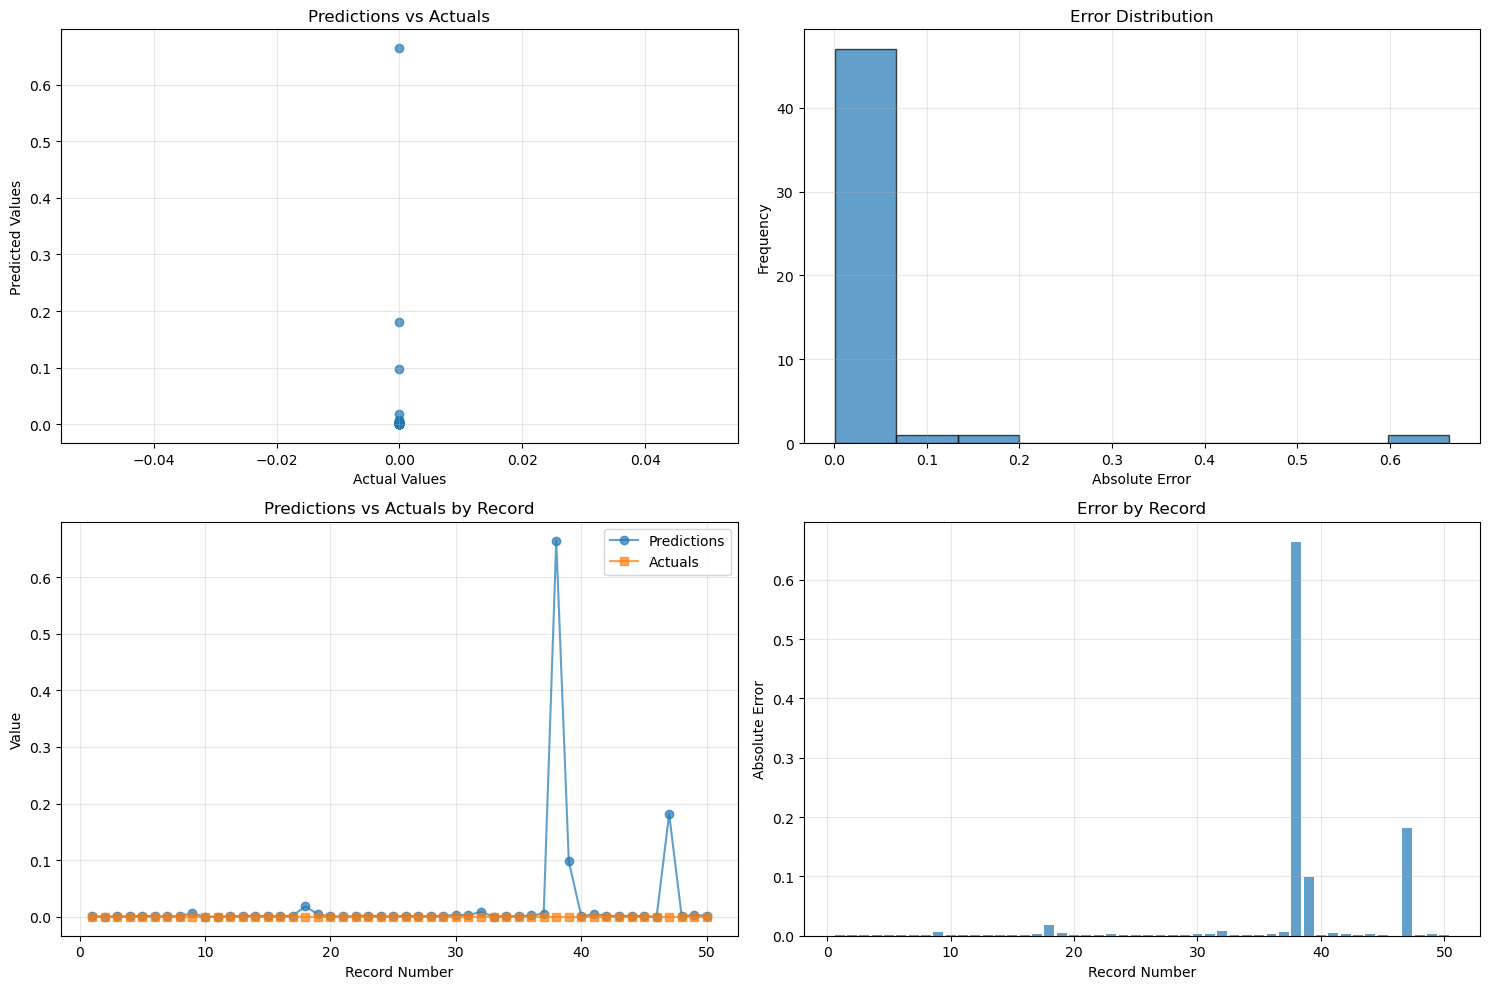

In [24]:
def analyze_results(results):
    """Analyze and visualize test results"""
    
    if not results:
        print("❌ No results to analyze")
        return
    
    successful_results = [r for r in results if r['prediction'] is not None]
    
    if not successful_results:
        print("❌ No successful predictions to analyze")
        return
    
    # Extract data for analysis
    predictions = [r['prediction'] for r in successful_results]
    actuals = [r['actual'] for r in successful_results]
    errors = [r['error'] for r in successful_results]
    
    # Print summary statistics
    print("📊 SUMMARY STATISTICS:")
    print(f"Total records: {len(results)}")
    print(f"Successful predictions: {len(successful_results)}")
    print(f"Failed predictions: {len(results) - len(successful_results)}")
    print(f"Average prediction: {np.mean(predictions):.2f}")
    print(f"Average actual: {np.mean(actuals):.2f}")
    print(f"Mean Absolute Error: {np.mean(errors):.2f}")
    print(f"Min Error: {np.min(errors):.2f}")
    print(f"Max Error: {np.max(errors):.2f}")
    print(f"Standard Deviation of Errors: {np.std(errors):.2f}")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Predictions vs Actuals scatter plot
    axes[0, 0].scatter(actuals, predictions, alpha=0.7)
    axes[0, 0].plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], 'r--', lw=2)
    axes[0, 0].set_xlabel('Actual Values')
    axes[0, 0].set_ylabel('Predicted Values')
    axes[0, 0].set_title('Predictions vs Actuals')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Error distribution histogram
    axes[0, 1].hist(errors, bins=10, alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Absolute Error')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Error Distribution')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Predictions and actuals over records
    record_nums = [r['record'] for r in successful_results]
    axes[1, 0].plot(record_nums, predictions, 'o-', label='Predictions', alpha=0.7)
    axes[1, 0].plot(record_nums, actuals, 's-', label='Actuals', alpha=0.7)
    axes[1, 0].set_xlabel('Record Number')
    axes[1, 0].set_ylabel('Value')
    axes[1, 0].set_title('Predictions vs Actuals by Record')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Error by record
    axes[1, 1].bar(record_nums, errors, alpha=0.7)
    axes[1, 1].set_xlabel('Record Number')
    axes[1, 1].set_ylabel('Absolute Error')
    axes[1, 1].set_title('Error by Record')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'total_records': len(results),
        'successful_predictions': len(successful_results),
        'mean_absolute_error': np.mean(errors),
        'predictions': predictions,
        'actuals': actuals,
        'errors': errors
    }

# Analyze results
if results:
    analysis = analyze_results(results)
else:
    print("⚠️  No results to analyze")

## 6. Custom Testing Function

Create your own test data and run predictions.

In [28]:
# Custom test scenarios for bank marketing model
# Define scenarios as dictionaries matching the original feature names
custom_scenarios = [
    {  # Young professional, short call
        'age': 25, 'job': 'technician', 'marital': 'single', 'education': 'university.degree',
        'default': 'no', 'housing': 'yes', 'loan': 'no', 'contact': 'cellular',
        'month': 'may', 'day_of_week': 'mon', 'duration': 120, 'campaign': 1,
        'pdays': 999, 'previous': 0, 'poutcome': 'nonexistent',
        'emp.var.rate': 1.1, 'cons.price.idx': 93.994, 'cons.conf.idx': -36.4,
        'euribor3m': 4.857, 'nr.employed': 5191.0
    },
    {  # Retired, long call, previous success
        'age': 65, 'job': 'retired', 'marital': 'married', 'education': 'basic.4y',
        'default': 'no', 'housing': 'no', 'loan': 'no', 'contact': 'cellular',
        'month': 'mar', 'day_of_week': 'thu', 'duration': 500, 'campaign': 1,
        'pdays': 3, 'previous': 1, 'poutcome': 'success',
        'emp.var.rate': -1.8, 'cons.price.idx': 92.893, 'cons.conf.idx': -46.2,
        'euribor3m': 1.299, 'nr.employed': 5099.1
    },
    {  # Blue collar, many campaigns, no previous contact
        'age': 40, 'job': 'blue-collar', 'marital': 'married', 'education': 'basic.9y',
        'default': 'unknown', 'housing': 'yes', 'loan': 'yes', 'contact': 'telephone',
        'month': 'jun', 'day_of_week': 'fri', 'duration': 60, 'campaign': 5,
        'pdays': 999, 'previous': 0, 'poutcome': 'nonexistent',
        'emp.var.rate': 1.4, 'cons.price.idx': 94.465, 'cons.conf.idx': -41.8,
        'euribor3m': 4.959, 'nr.employed': 5228.1
    },
]

scenario_names = ['Young professional (short call)', 'Retired (long call, prev success)', 'Blue collar (many campaigns)']

# Preprocess custom scenarios using the same pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Read full dataset to fit the preprocessor (same as training)
bank_file = os.path.join('data', 'bank-marketing-dataset.csv')
df_full = pd.read_csv(bank_file, sep=';', quotechar='"')

numeric_features = ['age', 'duration', 'campaign', 'pdays', 'previous',
                    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                        'contact', 'month', 'day_of_week', 'poutcome']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Fit on full dataset
X_full = df_full[numeric_features + categorical_features]
preprocess.fit(X_full)

# Transform custom scenarios
df_custom = pd.DataFrame(custom_scenarios)
X_custom = preprocess.transform(df_custom[numeric_features + categorical_features])

print('Testing with custom scenarios:')
print('-' * 70)
custom_results = []

for i, (row, name) in enumerate(zip(X_custom, scenario_names), 1):
    test_data = ','.join([str(x) for x in row])
    if endpoint_name:
        try:
            response = runtime_client.invoke_endpoint(
                EndpointName=endpoint_name,
                ContentType='text/csv',
                Body=test_data
            )
            prediction = float(response['Body'].read().decode().strip())
            custom_results.append(prediction)
            print(f'Test {i} ({name}):')
            print(f'  Prediction: {prediction:.4f} (subscribe probability)')
            print()
        except Exception as e:
            print(f'Error in test {i}: {e}')
            custom_results.append(None)
    else:
        print('No endpoint available for testing')
        break

print(f'Custom test results: {custom_results}')

Testing with custom scenarios:
----------------------------------------------------------------------
Test 1 (Young professional (short call)):
  Prediction: 0.0017 (subscribe probability)

Test 2 (Retired (long call, prev success)):
  Prediction: 0.4870 (subscribe probability)

Test 3 (Blue collar (many campaigns)):
  Prediction: 0.0001 (subscribe probability)

Custom test results: [0.0017364943632856011, 0.48700249195098877, 0.0001432650606147945]


## 7. Summary and Next Steps

This notebook demonstrated:
1. ✅ Endpoint discovery and basic testing
2. ✅ Real data preprocessing and batch testing
3. ✅ Results analysis and visualization
4. ✅ Custom data testing

### Next Steps:
- Check CloudWatch dashboards for endpoint metrics
- Explore captured data in S3 for model monitoring
- Set up automated testing pipelines
- Configure alerts for endpoint performance

In [29]:
# Final summary
print("🎉 WORKSHOP COMPLETE!")
print("\n📋 Summary:")
if endpoint_name:
    print(f"✅ Tested endpoint: {endpoint_name}")
results = results if 'results' in dir() else []
if results:
    successful = len([r for r in results if r['prediction'] is not None])
    print(f"✅ Batch tests: {successful}/{len(results)} successful")
custom_results = custom_results if 'custom_results' in dir() else []
if custom_results:
    successful_custom = len([r for r in custom_results if r is not None])
    print(f"✅ Custom tests: {successful_custom}/{len(custom_results)} successful")
data_capture_config = data_capture_config if 'data_capture_config' in dir() else None
if data_capture_config:
    print(f"✅ Data capture: {data_capture_config['CaptureStatus']} ({data_capture_config['CurrentSamplingPercentage']}%)")

print("\n🔗 Useful Links:")
print("- AWS Console → SageMaker → Endpoints")


🎉 WORKSHOP COMPLETE!

📋 Summary:
✅ Tested endpoint: aiops-3rcq0htthb46cn-models-endpoint-20260812153320
✅ Batch tests: 50/50 successful
✅ Custom tests: 3/3 successful

🔗 Useful Links:
- AWS Console → SageMaker → Endpoints
